In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from mlxtend.frequent_patterns import apriori, association_rules
from warnings import filterwarnings
filterwarnings("ignore")
import networkx as nx

In [3]:
grocery = pd.read_csv("Groceries_dataset.csv")
grocery

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
...,...,...,...
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice


In [4]:
grocery[grocery.duplicated()]

,Member_number,Date,itemDescription
5015,2051,11-09-2015,frankfurter
5022,3055,18-08-2015,other vegetables
5044,1994,11-03-2015,whole milk
5055,1682,25-06-2015,pip fruit
5059,4324,05-01-2015,sausage
...,...,...,...
38614,2027,26-02-2014,domestic eggs
38684,2936,07-03-2014,newspapers
38685,2311,13-03-2014,pot plants
38722,3834,18-05-2014,salty snack


In [5]:
grocer1=grocery.drop_duplicates()
grocer1

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
...,...,...,...
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice


In [6]:
grocer1['Date'] = pd.to_datetime(grocer1['Date'])
grocer1.sort_values('Date')

,Member_number,Date,itemDescription
35406,3681,2014-01-01,dishes
12744,1789,2014-01-01,hamburger meat
13247,2610,2014-01-01,hamburger meat
26214,1249,2014-01-01,coffee
29730,4942,2014-01-01,frozen vegetables
...,...,...,...
17347,3971,2015-12-30,bottled beer
16428,2970,2015-12-30,meat
1134,4863,2015-12-30,dessert
34960,3562,2015-12-30,rolls/buns


In [7]:
grocer1.Member_number.nunique()

3898

In [8]:
grocer1.itemDescription.nunique()

167

In [9]:
grocer1.itemDescription.unique()

array(['tropical fruit', 'whole milk', 'pip fruit', 'other vegetables',
       'rolls/buns', 'pot plants', 'citrus fruit', 'beef', 'frankfurter',
       'chicken', 'butter', 'fruit/vegetable juice',
       'packaged fruit/vegetables', 'chocolate', 'specialty bar',
       'butter milk', 'bottled water', 'yogurt', 'sausage', 'brown bread',
       'hamburger meat', 'root vegetables', 'pork', 'pastry',
       'canned beer', 'berries', 'coffee', 'misc. beverages', 'ham',
       'turkey', 'curd cheese', 'red/blush wine',
       'frozen potato products', 'flour', 'sugar', 'frozen meals',
       'herbs', 'soda', 'detergent', 'grapes', 'processed cheese', 'fish',
       'sparkling wine', 'newspapers', 'curd', 'pasta', 'popcorn',
       'finished products', 'beverages', 'bottled beer', 'dessert',
       'dog food', 'specialty chocolate', 'condensed milk', 'cleaner',
       'white wine', 'meat', 'ice cream', 'hard cheese', 'cream cheese ',
       'liquor', 'pickled vegetables', 'liquor (appetizer

In [10]:
grocer1['itemDescription'].value_counts().head(19)

itemDescription
whole milk            2363
other vegetables      1827
rolls/buns            1646
soda                  1453
yogurt                1285
root vegetables       1041
tropical fruit        1014
bottled water          908
sausage                903
citrus fruit           795
pastry                 774
pip fruit              734
shopping bags          712
canned beer            702
bottled beer           678
whipped/sour cream     654
newspapers             582
frankfurter            565
brown bread            563
Name: count, dtype: int64

In [11]:
trans_grocery=pd.crosstab(grocer1['Member_number'],grocer1['itemDescription']).reset_index()
trans_grocery1= trans_grocery.set_index('Member_number')
trans_grocery1

itemDescription,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
Member_number,,,,,,,,,,,,,,,,,,,,,
1000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,1,0
1001,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,1,0,2,0,0
1002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
4998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
item_list = grocery.itemDescription.unique()

In [13]:
rw=trans_grocery1.shape[0]
col=trans_grocery1.shape[1]
print(rw)
print(col)

3898
167


In [14]:
List_item = []
for i  in range(rw):
    temp=[]
    for j in item_list:
        if trans_grocery.loc[i,j]>=1:
            temp.append(j)
    List_item.append(temp)

List_item


[['whole milk',
  'yogurt',
  'sausage',
  'pastry',
  'canned beer',
  'misc. beverages',
  'soda',
  'pickled vegetables',
  'salty snack',
  'hygiene articles',
  'semi-finished bread'],
 ['whole milk',
  'rolls/buns',
  'beef',
  'frankfurter',
  'sausage',
  'soda',
  'curd',
  'whipped/sour cream',
  'white bread'],
 ['tropical fruit',
  'whole milk',
  'other vegetables',
  'butter',
  'butter milk',
  'sugar',
  'specialty chocolate',
  'frozen vegetables'],
 ['rolls/buns',
  'sausage',
  'root vegetables',
  'frozen meals',
  'detergent',
  'dental care'],
 ['tropical fruit',
  'whole milk',
  'pip fruit',
  'other vegetables',
  'rolls/buns',
  'packaged fruit/vegetables',
  'chocolate',
  'root vegetables',
  'pastry',
  'canned beer',
  'red/blush wine',
  'shopping bags',
  'dish cleaner',
  'cling film/bags',
  'frozen fish',
  'hygiene articles'],
 ['rolls/buns', 'margarine', 'whipped/sour cream'],
 ['whole milk',
  'rolls/buns',
  'frankfurter',
  'chicken',
  'chocolat

In [15]:
trans_grocery1['Item_List'] = List_item
trans_grocery1.head()

itemDescription,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback,Item_List
Member_number,,,,,,,,,,,,,,,,,,,,,
1000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,1,0,"[whole milk, yogurt, sausage, pastry, canned b..."
1001,0,0,0,0,0,0,0,0,1,0,...,0,0,1,0,1,0,2,0,0,"[whole milk, rolls/buns, beef, frankfurter, sa..."
1002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,"[tropical fruit, whole milk, other vegetables,..."
1003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[rolls/buns, sausage, root vegetables, frozen ..."
1004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,3,0,0,"[tropical fruit, whole milk, pip fruit, other ..."


In [16]:
basket_grocery = trans_grocery1[['Item_List']]
basket_grocery.head(10)

itemDescription,Item_List
Member_number,
1000,"[whole milk, yogurt, sausage, pastry, canned b..."
1001,"[whole milk, rolls/buns, beef, frankfurter, sa..."
1002,"[tropical fruit, whole milk, other vegetables,..."
1003,"[rolls/buns, sausage, root vegetables, frozen ..."
1004,"[tropical fruit, whole milk, pip fruit, other ..."
1005,"[rolls/buns, margarine, whipped/sour cream]"
1006,"[whole milk, rolls/buns, frankfurter, chicken,..."
1008,"[tropical fruit, yogurt, hamburger meat, root ..."
1009,"[tropical fruit, yogurt, pastry, herbs, newspa..."


In [17]:
trans_grocery2= trans_grocery1.drop(['Item_List'],axis=1)
trans_grocery2

itemDescription,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
Member_number,,,,,,,,,,,,,,,,,,,,,
1000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,1,0
1001,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,1,0,2,0,0
1002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
4998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
def encode_units(x):
    if x<1:
        return 0 
    if x>=1:
        return 1

basket_trans= trans_grocery2.applymap(encode_units)
basket_trans.head()

itemDescription,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
Member_number,,,,,,,,,,,,,,,,,,,,,
1000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
1001,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,1,0,1,0,0
1002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [19]:
whole_milk_grocery = basket_trans.loc[basket_trans['whole milk']==1]
whole_milk_grocery

itemDescription,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
Member_number,,,,,,,,,,,,,,,,,,,,,
1000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
1001,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,1,0,1,0,0
1002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1006,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4985,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4986,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4991,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0


In [20]:
frequent_itemsets = apriori(whole_milk_grocery,min_support=0.15,use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.186450,(bottled beer)
1,0.245241,(bottled water)
2,0.152296,(brown bread)
3,0.190370,(canned beer)
4,0.201568,(citrus fruit)
5,0.153415,(domestic eggs)
6,0.157895,(newspapers)
7,0.417693,(other vegetables)
8,0.198768,(pastry)
9,0.189810,(pip fruit)


In [21]:
whole_milk_rules = association_rules(frequent_itemsets,metric="lift",min_threshold=1)


In [22]:
whole_milk_rules.sort_values(['lift','support'],ascending=False).reset_index(drop=True)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(yogurt),(other vegetables),0.328667,0.417693,0.156775,0.477002,1.141991,1.0,0.019493,1.113401,0.185208,0.265907,0.101851,0.426168
1,"(yogurt, whole milk)",(other vegetables),0.328667,0.417693,0.156775,0.477002,1.141991,1.0,0.019493,1.113401,0.185208,0.265907,0.101851,0.426168
2,(yogurt),"(other vegetables, whole milk)",0.328667,0.417693,0.156775,0.477002,1.141991,1.0,0.019493,1.113401,0.185208,0.265907,0.101851,0.426168
3,(other vegetables),(yogurt),0.417693,0.328667,0.156775,0.375335,1.141991,1.0,0.019493,1.074708,0.213523,0.265907,0.069515,0.426168
4,"(other vegetables, whole milk)",(yogurt),0.417693,0.328667,0.156775,0.375335,1.141991,1.0,0.019493,1.074708,0.213523,0.265907,0.069515,0.426168
5,(other vegetables),"(yogurt, whole milk)",0.417693,0.328667,0.156775,0.375335,1.141991,1.0,0.019493,1.074708,0.213523,0.265907,0.069515,0.426168
6,(other vegetables),(rolls/buns),0.417693,0.389698,0.179171,0.428954,1.100736,1.0,0.016397,1.068745,0.157163,0.285205,0.064323,0.444362
7,(rolls/buns),(other vegetables),0.389698,0.417693,0.179171,0.459770,1.100736,1.0,0.016397,1.077887,0.149954,0.285205,0.072259,0.444362
8,"(other vegetables, whole milk)",(rolls/buns),0.417693,0.389698,0.179171,0.428954,1.100736,1.0,0.016397,1.068745,0.157163,0.285205,0.064323,0.444362
9,"(rolls/buns, whole milk)",(other vegetables),0.389698,0.417693,0.179171,0.459770,1.100736,1.0,0.016397,1.077887,0.149954,0.285205,0.072259,0.444362


In [23]:
def frequently_bought_togther(item):
    ## def of item is passed 
    item_df= basket_trans.loc[basket_trans[item]==1]
    ## applying apriori algorithms on item df 
    frequent_itemsets= apriori(item_df,min_support=0.15,use_colnames=True)
    #storing the association rules
    rules= association_rules(frequent_itemsets,metric='lift',min_threshold=1)
    #sorting on lift and support 
    rules.sort_values(['lift','support'],ascending=False).reset_index(drop=True)
    print('item frequntely bought together'.format(item))
    #returning top 6 item with high lift and support 
    return rules['consequents'].unique()[:6]



In [24]:
frequently_bought_togther('ice cream')

item frequntely bought together


array([frozenset({'ice cream'}), frozenset({'beef'}),
       frozenset({'bottled beer'}), frozenset({'bottled water'}),
       frozenset({'butter'}), frozenset({'canned beer'})], dtype=object)

In [25]:
grocery[grocery['Member_number']==2222]

,Member_number,Date,itemDescription
1631,2222,08-01-2015,yogurt
3796,2222,21-07-2015,berries
4881,2222,28-12-2015,whole milk
8433,2222,28-12-2015,sausage
10571,2222,13-02-2014,grapes
11296,2222,03-04-2014,pork
14695,2222,31-07-2014,sugar
15709,2222,21-07-2015,other vegetables
17780,2222,08-01-2015,dental care
19945,2222,21-07-2015,butter


In [26]:
cat_df= basket_trans.loc[basket_trans['whole milk']==1]
frequent_itemsets= apriori(cat_df,min_support=0.15,use_colnames=True)
rules = association_rules(frequent_itemsets,metric='lift',min_threshold=1)
top_rules = rules.sort_values(by='lift',ascending=False).head(10)
top_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
58,(yogurt),"(other vegetables, whole milk)",0.328667,0.417693,0.156775,0.477002,1.141991,1.0,0.019493,1.113401,0.185208,0.265907,0.101851,0.426168
56,"(yogurt, whole milk)",(other vegetables),0.328667,0.417693,0.156775,0.477002,1.141991,1.0,0.019493,1.113401,0.185208,0.265907,0.101851,0.426168
21,(yogurt),(other vegetables),0.328667,0.417693,0.156775,0.477002,1.141991,1.0,0.019493,1.113401,0.185208,0.265907,0.101851,0.426168
20,(other vegetables),(yogurt),0.417693,0.328667,0.156775,0.375335,1.141991,1.0,0.019493,1.074708,0.213523,0.265907,0.069515,0.426168
57,(other vegetables),"(yogurt, whole milk)",0.417693,0.328667,0.156775,0.375335,1.141991,1.0,0.019493,1.074708,0.213523,0.265907,0.069515,0.426168
55,"(other vegetables, whole milk)",(yogurt),0.417693,0.328667,0.156775,0.375335,1.141991,1.0,0.019493,1.074708,0.213523,0.265907,0.069515,0.426168
43,"(other vegetables, whole milk)",(rolls/buns),0.417693,0.389698,0.179171,0.428954,1.100736,1.0,0.016397,1.068745,0.157163,0.285205,0.064323,0.444362
44,"(rolls/buns, whole milk)",(other vegetables),0.389698,0.417693,0.179171,0.459770,1.100736,1.0,0.016397,1.077887,0.149954,0.285205,0.072259,0.444362
45,(other vegetables),"(rolls/buns, whole milk)",0.417693,0.389698,0.179171,0.428954,1.100736,1.0,0.016397,1.068745,0.157163,0.285205,0.064323,0.444362
46,(rolls/buns),"(other vegetables, whole milk)",0.389698,0.417693,0.179171,0.459770,1.100736,1.0,0.016397,1.077887,0.149954,0.285205,0.072259,0.444362


In [27]:
top_rules['antecedents_str']= top_rules['antecedents'].apply(lambda x: ','.join(list(x)))
top_rules['consequents_str']= top_rules['consequents'].apply(lambda x: ','.join(list(x)))
top_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedents_str,consequents_str
58,(yogurt),"(other vegetables, whole milk)",0.328667,0.417693,0.156775,0.477002,1.141991,1.0,0.019493,1.113401,0.185208,0.265907,0.101851,0.426168,yogurt,"other vegetables,whole milk"
56,"(yogurt, whole milk)",(other vegetables),0.328667,0.417693,0.156775,0.477002,1.141991,1.0,0.019493,1.113401,0.185208,0.265907,0.101851,0.426168,"yogurt,whole milk",other vegetables
21,(yogurt),(other vegetables),0.328667,0.417693,0.156775,0.477002,1.141991,1.0,0.019493,1.113401,0.185208,0.265907,0.101851,0.426168,yogurt,other vegetables
20,(other vegetables),(yogurt),0.417693,0.328667,0.156775,0.375335,1.141991,1.0,0.019493,1.074708,0.213523,0.265907,0.069515,0.426168,other vegetables,yogurt
57,(other vegetables),"(yogurt, whole milk)",0.417693,0.328667,0.156775,0.375335,1.141991,1.0,0.019493,1.074708,0.213523,0.265907,0.069515,0.426168,other vegetables,"yogurt,whole milk"
55,"(other vegetables, whole milk)",(yogurt),0.417693,0.328667,0.156775,0.375335,1.141991,1.0,0.019493,1.074708,0.213523,0.265907,0.069515,0.426168,"other vegetables,whole milk",yogurt
43,"(other vegetables, whole milk)",(rolls/buns),0.417693,0.389698,0.179171,0.428954,1.100736,1.0,0.016397,1.068745,0.157163,0.285205,0.064323,0.444362,"other vegetables,whole milk",rolls/buns
44,"(rolls/buns, whole milk)",(other vegetables),0.389698,0.417693,0.179171,0.459770,1.100736,1.0,0.016397,1.077887,0.149954,0.285205,0.072259,0.444362,"rolls/buns,whole milk",other vegetables
45,(other vegetables),"(rolls/buns, whole milk)",0.417693,0.389698,0.179171,0.428954,1.100736,1.0,0.016397,1.068745,0.157163,0.285205,0.064323,0.444362,other vegetables,"rolls/buns,whole milk"
46,(rolls/buns),"(other vegetables, whole milk)",0.389698,0.417693,0.179171,0.459770,1.100736,1.0,0.016397,1.077887,0.149954,0.285205,0.072259,0.444362,rolls/buns,"other vegetables,whole milk"


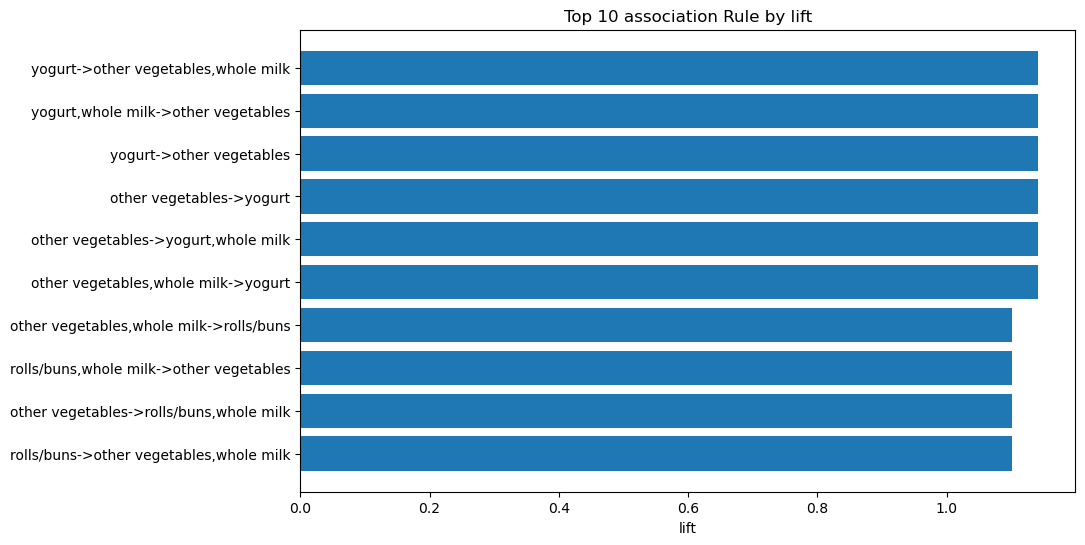

In [28]:
plt.figure(figsize=(10,6))
plt.barh(range(len(top_rules)),top_rules['lift'],tick_label=top_rules['antecedents_str']+'->'+top_rules['consequents_str'])
plt.xlabel('lift')
plt.title('Top 10 association Rule by lift')
plt.gca().invert_yaxis()
plt.show()

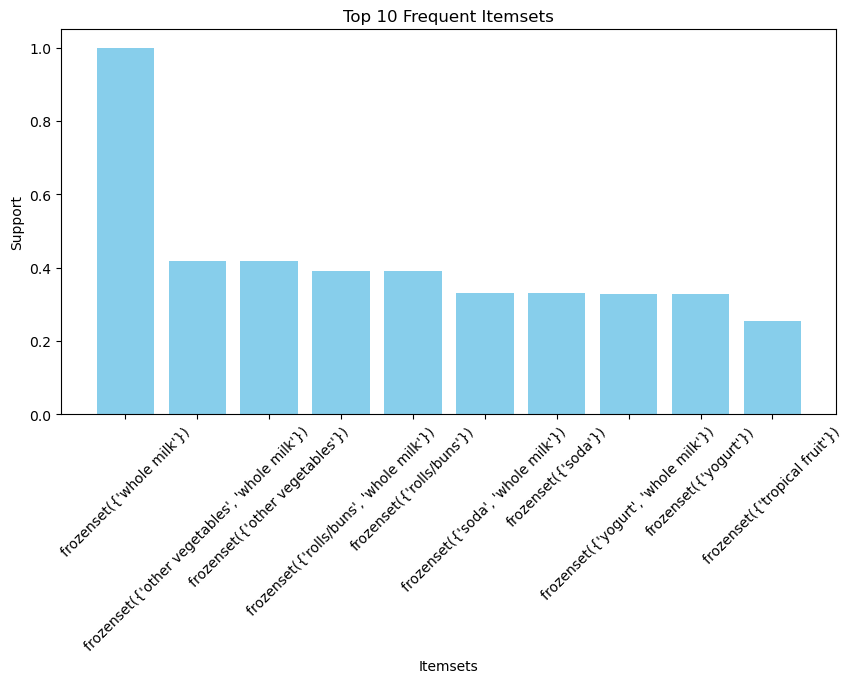

In [29]:
import matplotlib.pyplot as plt

# Sort frequent itemsets by support
top_items = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_items['itemsets'].astype(str), top_items['support'], color='skyblue')
plt.xticks(rotation=45)
plt.xlabel('Itemsets')
plt.ylabel('Support')
plt.title('Top 10 Frequent Itemsets')
plt.savefig("top_10_association_rules.png")
plt.show()

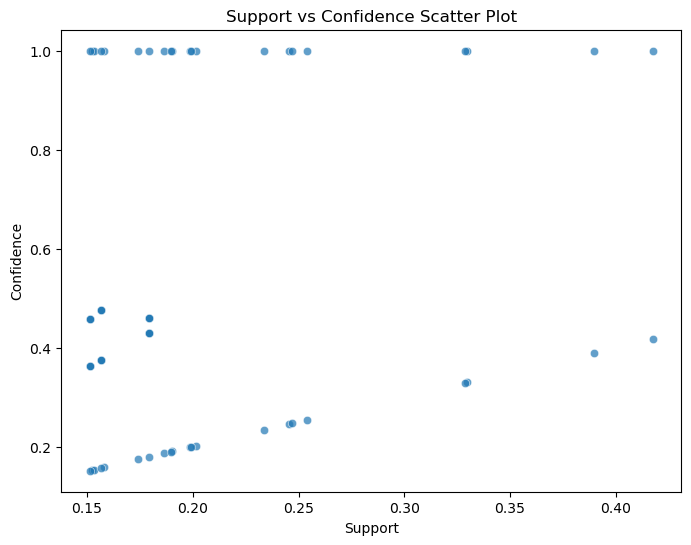

In [30]:


import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=rules['support'], y=rules['confidence'], alpha=0.7)
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence Scatter Plot')
plt.savefig(" Support vs Confidence.png")
plt.show()

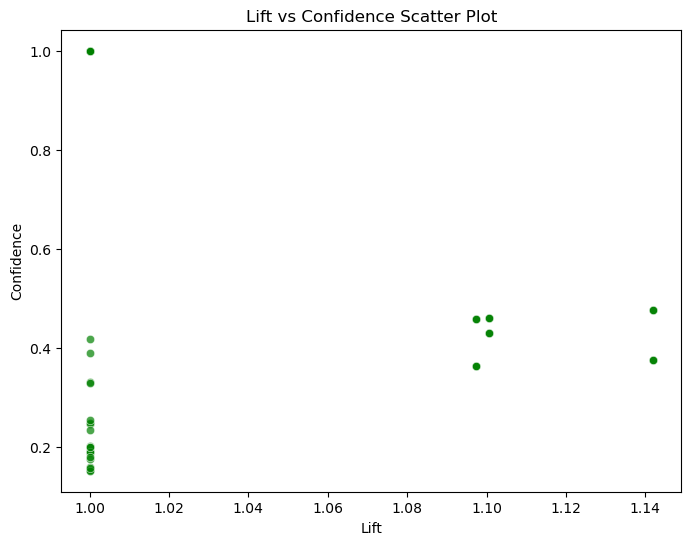

In [31]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=rules['lift'], y=rules['confidence'], alpha=0.7, color='green')
plt.xlabel('Lift')
plt.ylabel('Confidence')
plt.title('Lift vs Confidence Scatter Plot')
plt.savefig('Lift vs Confidence.png')
plt.show()

In [32]:
from mlxtend.preprocessing import TransactionEncoder
grocery = grocery.astype(str)
# Convert dataset into transaction format
te = TransactionEncoder()
te_array = te.fit(grocery.values.tolist()).transform(grocery.values.tolist())
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

In [ ]:
import numpy as np
import seaborn as sns

# Create co-occurrence matrix
item_matrix = df_encoded.T.dot(df_encoded)

# Convert diagonal values to zero (self-pairing not needed)
np.fill_diagonal(item_matrix.values, 0)

plt.figure(figsize=(12, 8))
sns.heatmap(item_matrix, cmap="Blues", annot=False)
plt.title('Item Co-occurrence Heatmap')
plt.savefig('Item Co-occurrence Heatmap.png')
plt.show()

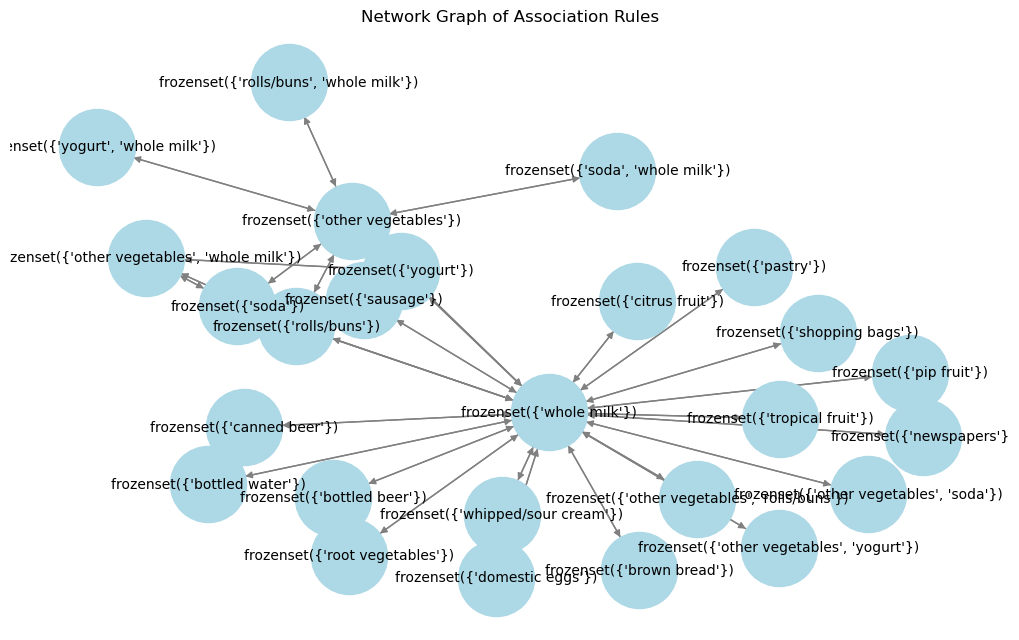

In [33]:
import networkx as nx

G = nx.DiGraph()
for _, row in rules.iterrows():
    G.add_edge(str(row['antecedents']), str(row['consequents']), weight=row['lift'])

plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", node_size=3000, font_size=10)
plt.title('Network Graph of Association Rules')
plt.savefig('Network Graph of Association Rules.png')
plt.show()

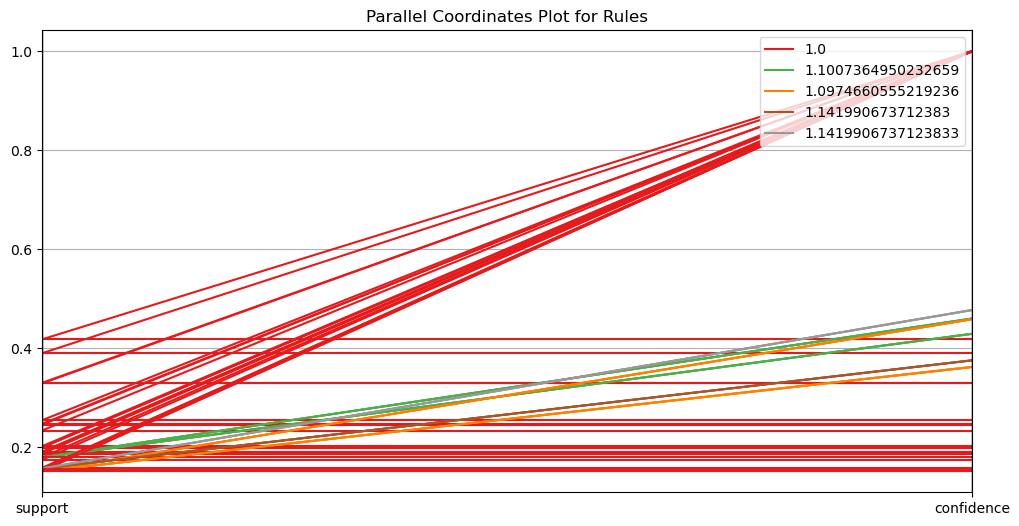

In [34]:
from pandas.plotting import parallel_coordinates

if not rules.empty:
    plt.figure(figsize=(12,6))
    parallel_coordinates(rules[['support', 'confidence', 'lift']], class_column='lift', colormap=plt.cm.Set1)
    plt.title('Parallel Coordinates Plot for Rules')
    plt.savefig('Parallel Coordinates Plot for Rules.png')
    plt.show()

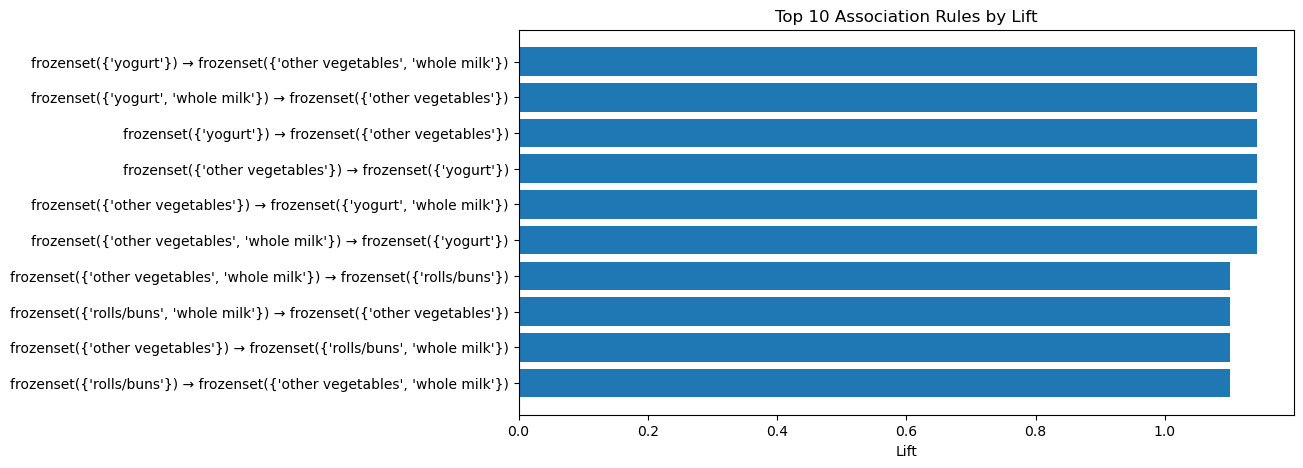

In [35]:
top_rules = rules.sort_values(by='lift', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(range(len(top_rules)), top_rules['lift'], tick_label=top_rules['antecedents'].astype(str) + ' → ' + top_rules['consequents'].astype(str))
plt.xlabel('Lift')
plt.title('Top 10 Association Rules by Lift')
plt.gca().invert_yaxis()
plt.savefig('Top 10 Association Rules by Lift.png')
plt.show()

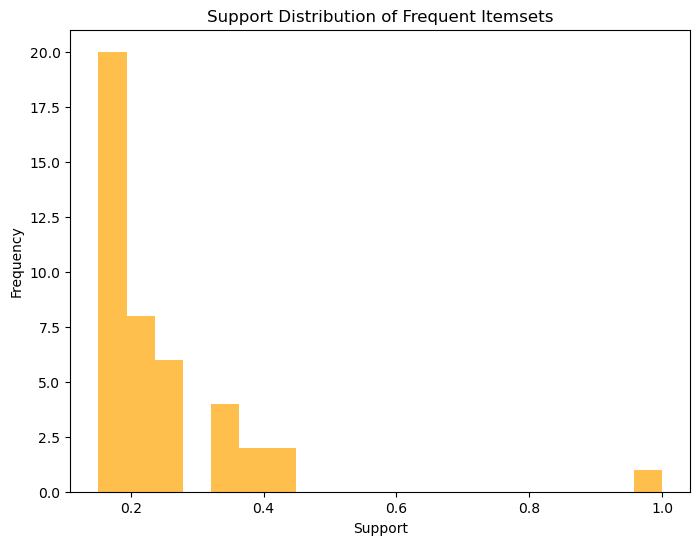

In [36]:
plt.figure(figsize=(8,6))
plt.hist(frequent_itemsets['support'], bins=20, color='orange', alpha=0.7)
plt.xlabel('Support')
plt.ylabel('Frequency')
plt.title('Support Distribution of Frequent Itemsets')
plt.savefig('Support Distribution of Frequent Itemsets.png')
plt.show()

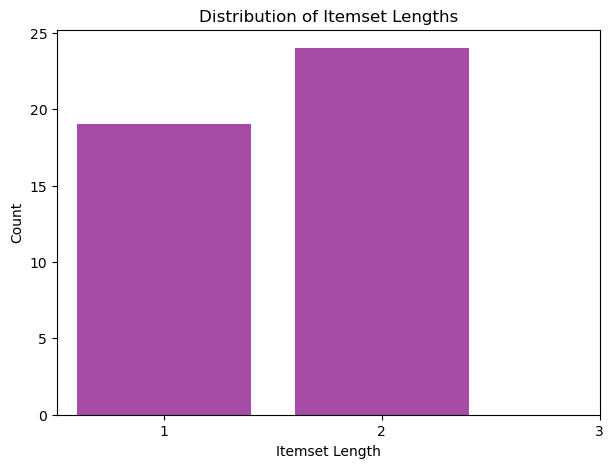

In [37]:
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

plt.figure(figsize=(7,5))
plt.hist(frequent_itemsets['length'], bins=range(1, frequent_itemsets['length'].max()+1), color='purple', alpha=0.7, align='left', rwidth=0.8)
plt.xlabel('Itemset Length')
plt.ylabel('Count')
plt.title('Distribution of Itemset Lengths')
plt.xticks(range(1, frequent_itemsets['length'].max()+1))
plt.savefig('Distribution of Itemset Lengths.png')
plt.show()

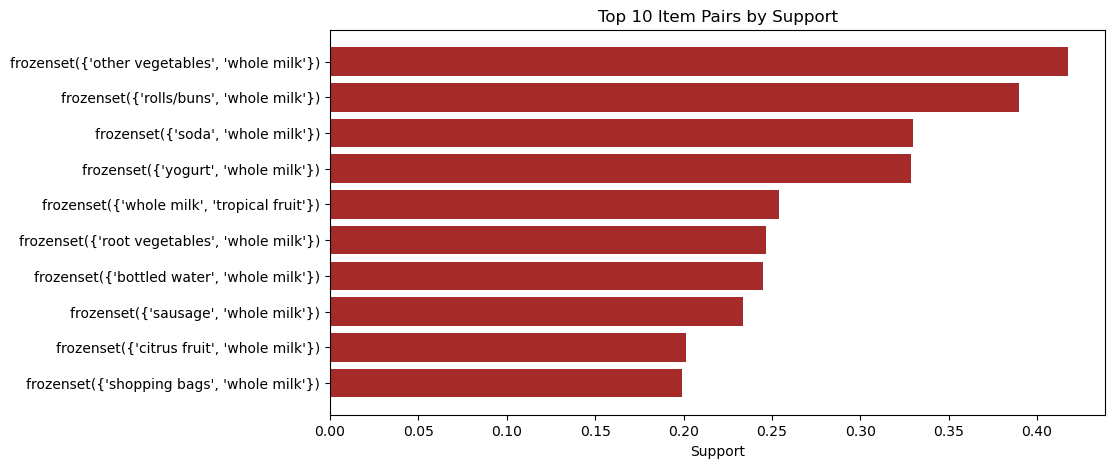

In [38]:
top_pairs = frequent_itemsets[frequent_itemsets['length'] == 2].sort_values(by='support', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(top_pairs['itemsets'].astype(str), top_pairs['support'], color='brown')
plt.xlabel('Support')
plt.title('Top 10 Item Pairs by Support')
plt.gca().invert_yaxis()
plt.savefig('Top 10 Item Pairs by Support.png')
plt.show()